# Analysis of the results from MGSD tests

MGSD dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [42]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

# Zero-shot
### Analysis results zero-shot - stereotype detection

In [44]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


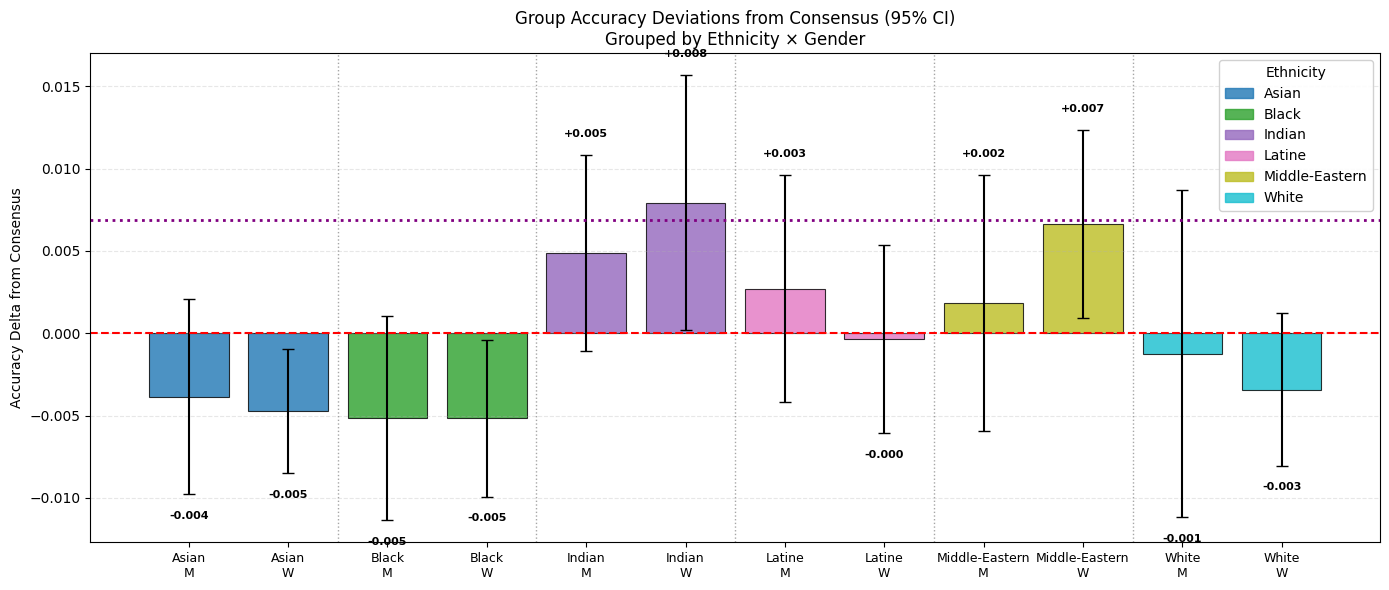


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.004    [-0.010, +0.002]5    
asian_woman         -0.005    [-0.008, -0.001]5    
black_man           -0.005    [-0.011, +0.001]5    
black_woman         -0.005    [-0.010, -0.000]5    
indian_man          +0.005    [-0.001, +0.011]5    
indian_woman        +0.008    [+0.000, +0.016]5    
latine_man          +0.003    [-0.004, +0.010]5    
latine_woman        -0.000    [-0.006, +0.005]5    
middle_eastern_man  +0.002    [-0.006, +0.010]5    
middle_eastern_woman+0.007    [+0.001, +0.012]5    
white_man           -0.001    [-0.011, +0.009]5    
white_woman         -0.003    [-0.008, +0.001]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: stereotype
Category columns analyzed: ['stereotype_type']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [45]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 64)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 64)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.726000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.713000  0.006275
woman      30  0.713267  0.006378

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7092  0.003795
black              10  0.7084  0.004195
indian             10 

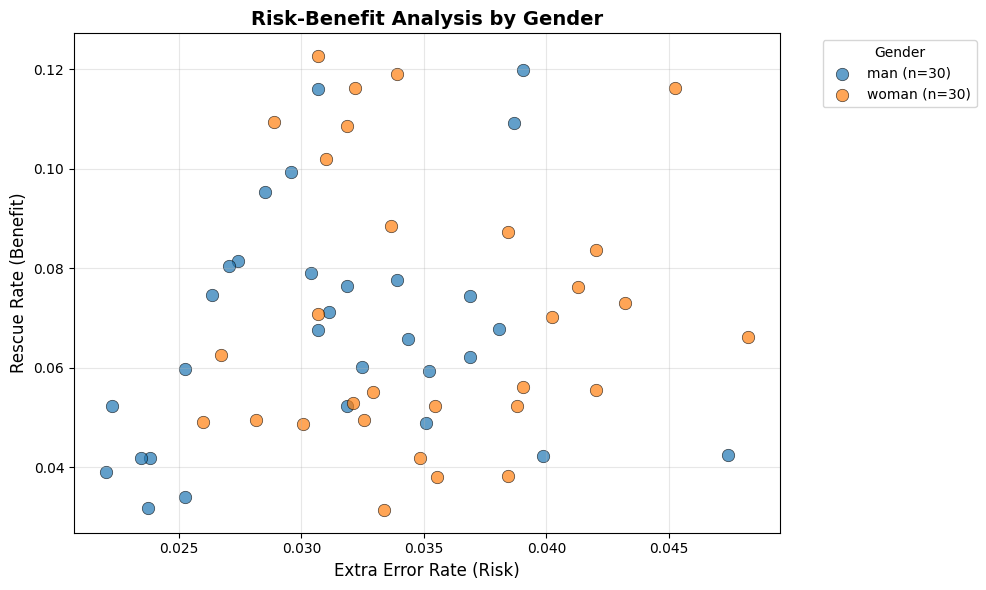


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


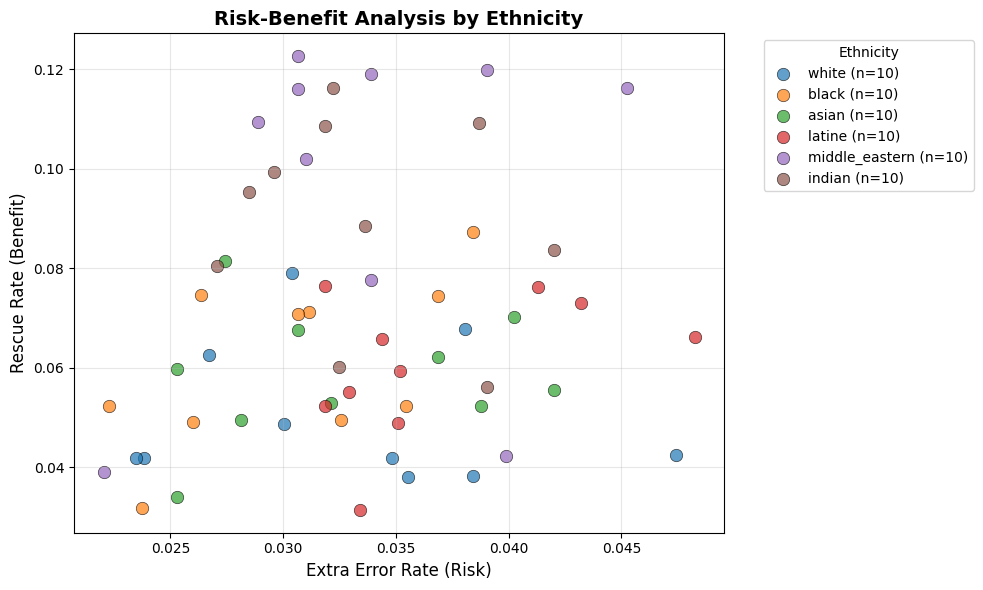


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


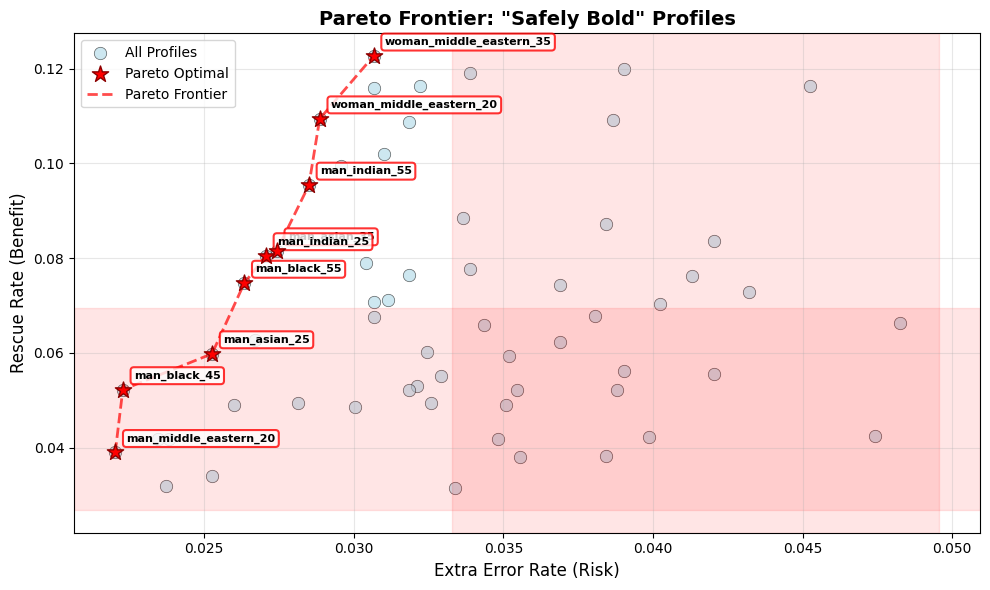


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 16
  man_indian_25 (profile52)
    Rescue Rate: 0.081, E

In [46]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:
--

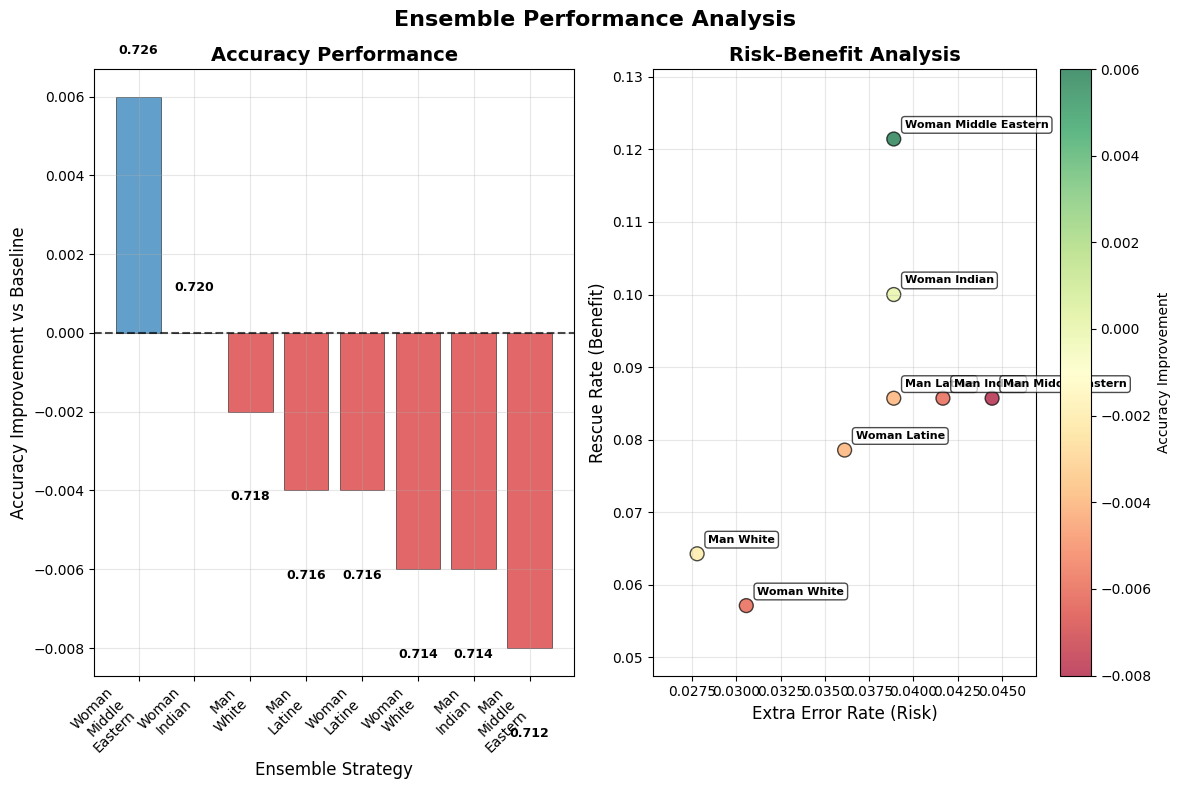

2. Cluster Analysis...


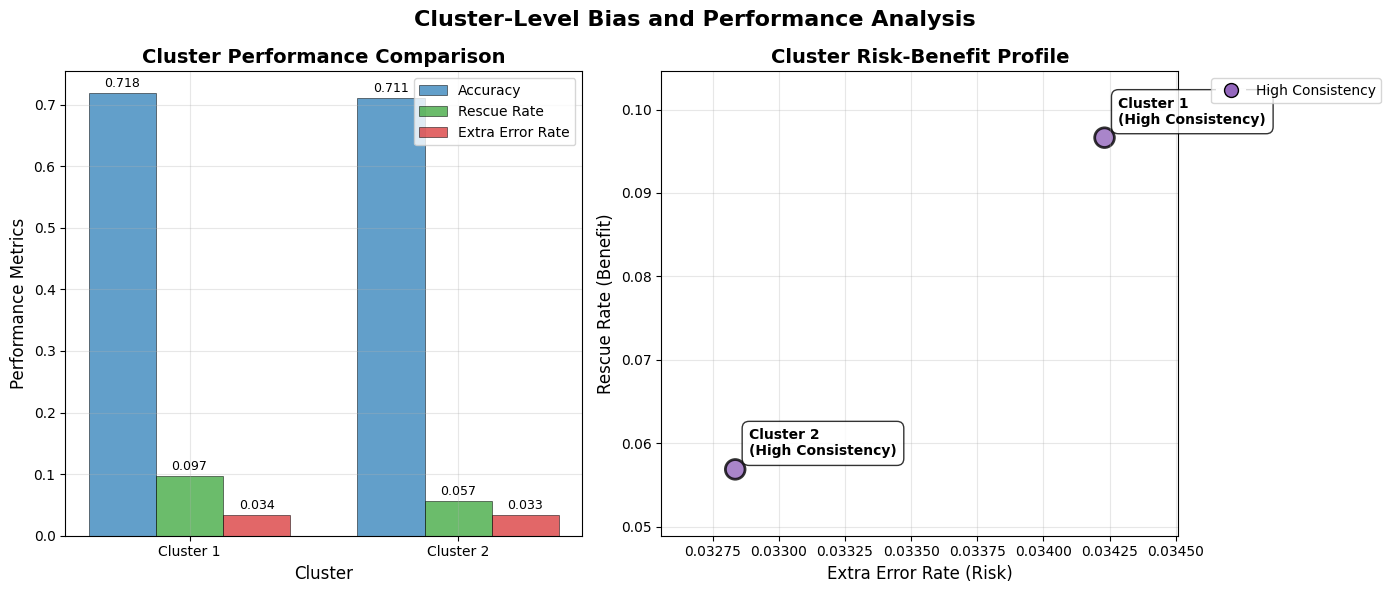

4. System-Level Recommendations...


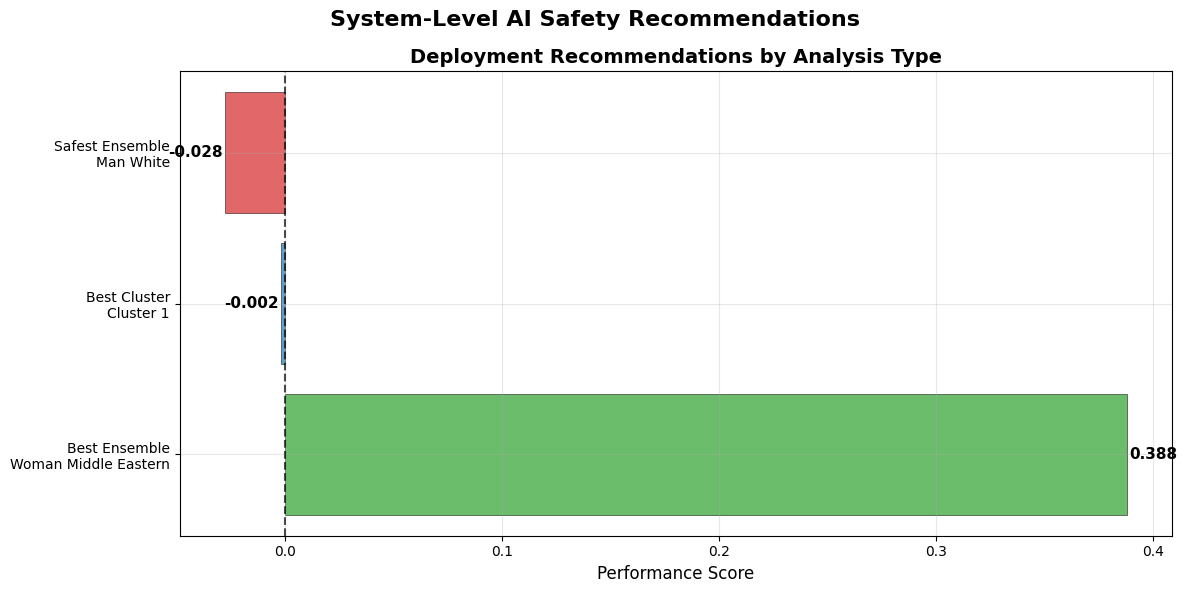


Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_middle_eastern
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [47]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in stereotype_type: ['gender', 'profession', 'race', 'religion']
Creating simplified boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.171, p=0.1920 
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=0.172, p=0.1897 
    → Negative correlation means more consistent 

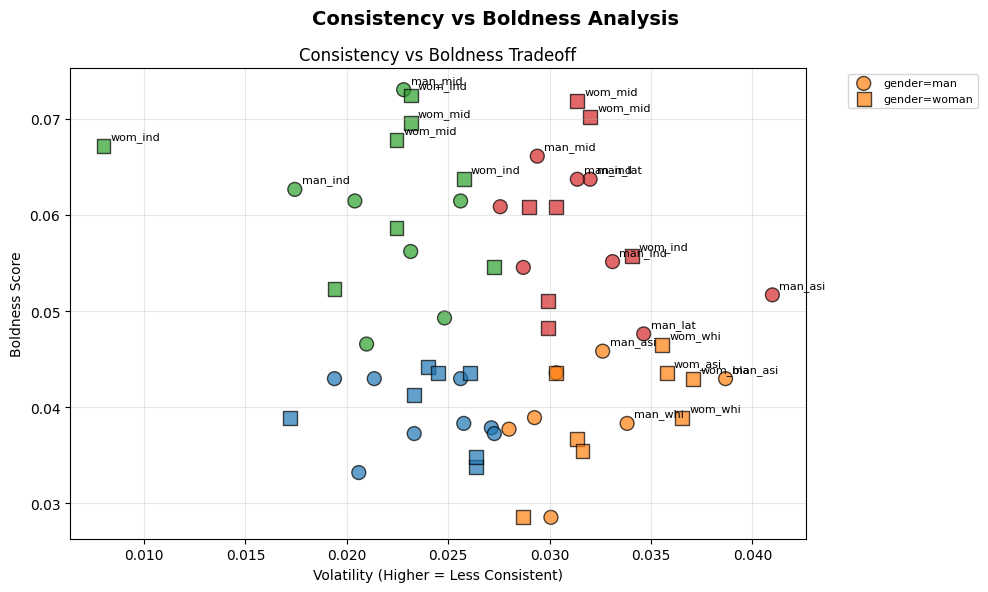

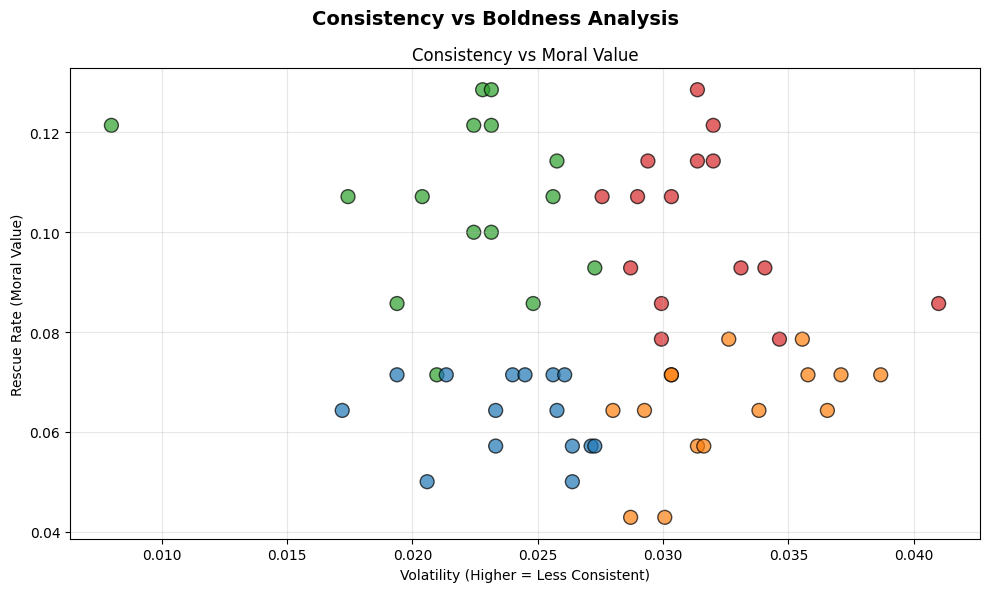

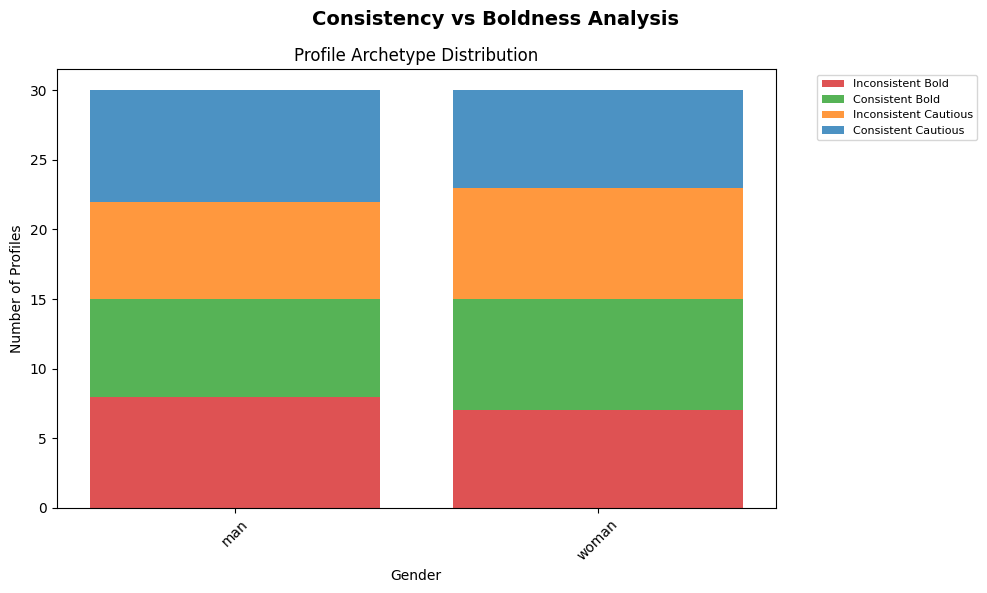

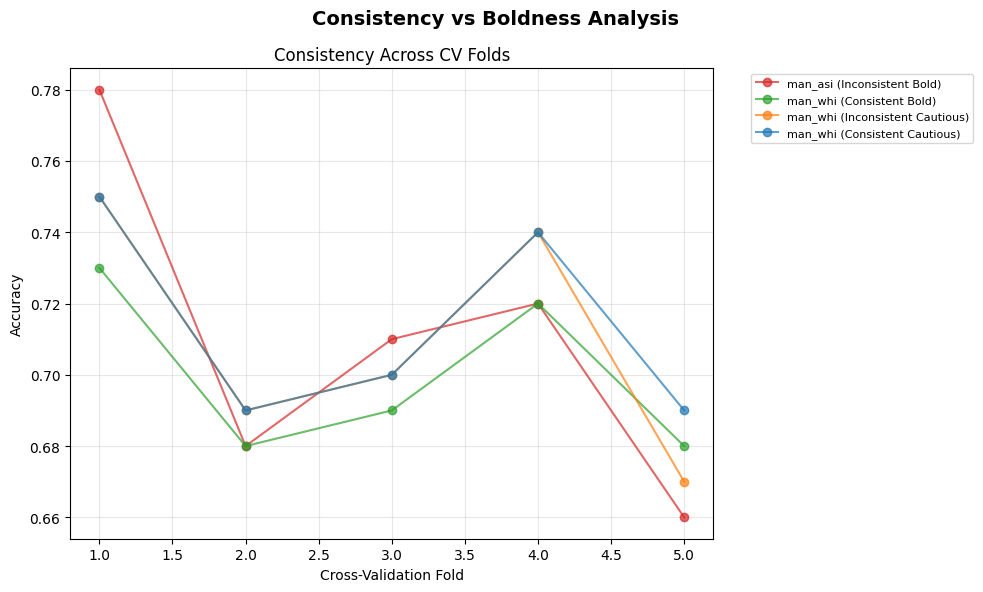

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


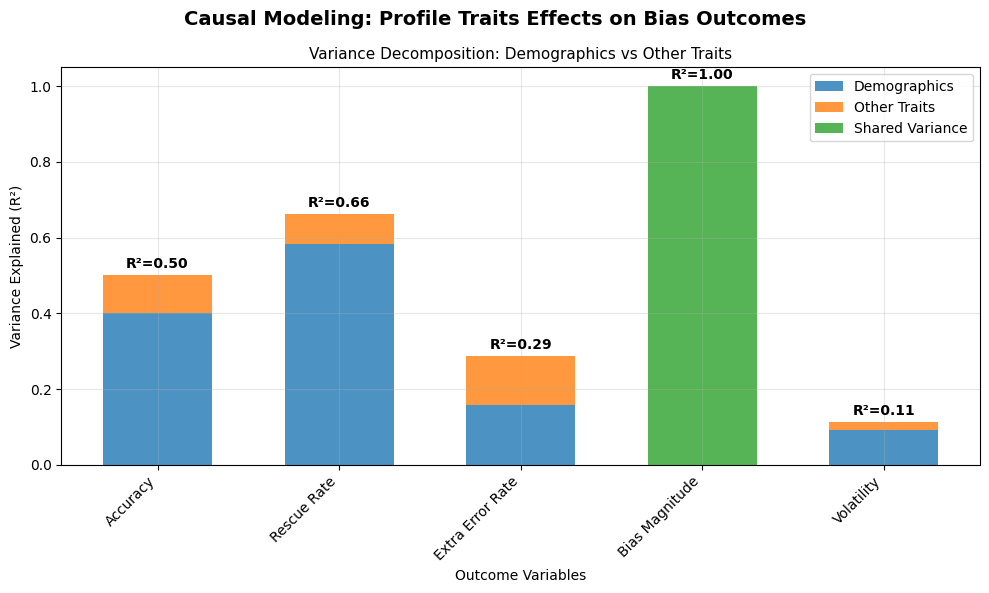

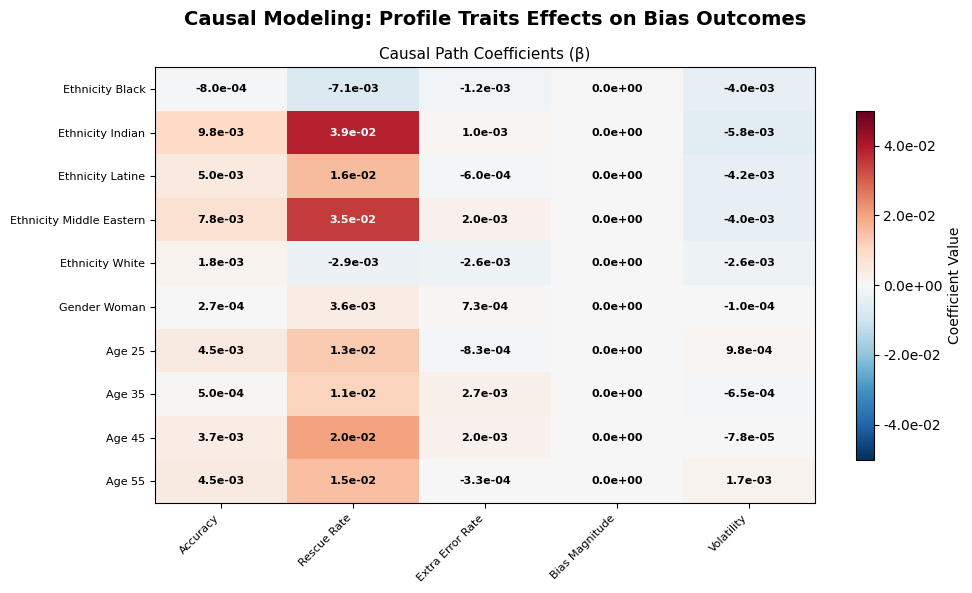

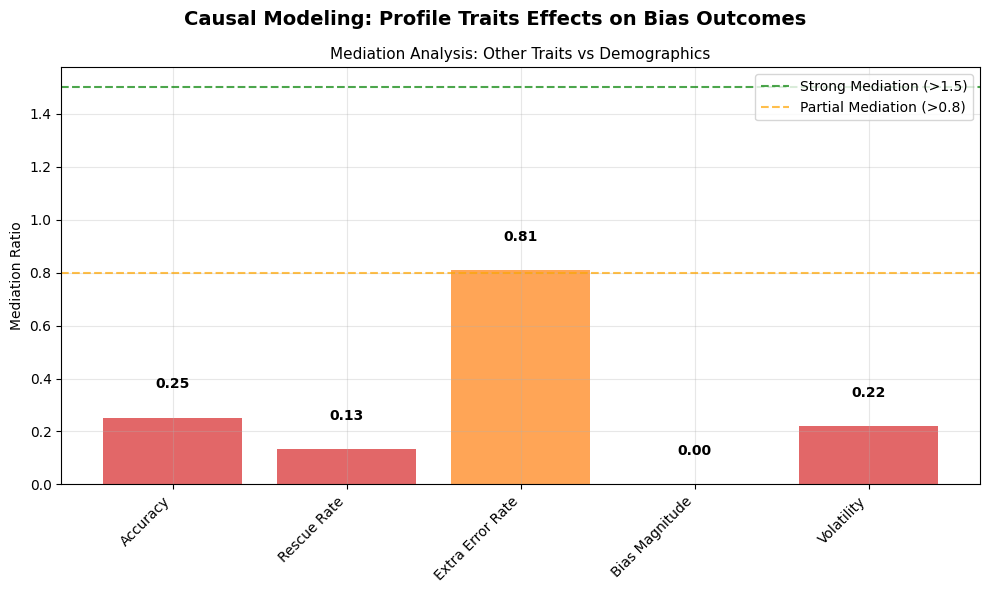

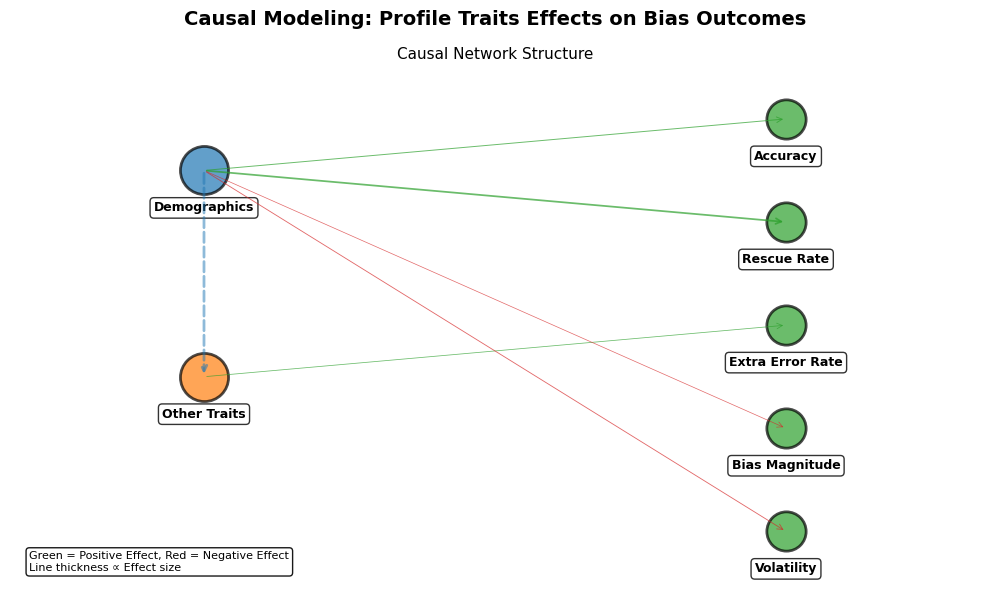

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.083 vs Consistent: 0.085
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 2 high, 2 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [48]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [49]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -3.180 (Large)
 2. indian_vs_latine                    Effect Size:  2.567 (Large)
 3. indian_vs_white                     Effect Size:  1.903 (Large)
 4. asian_vs_indian                     Effect Size: -1.859 (Large)
 5. black_vs_middle_eastern             Effect Size: -1.395 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.716 | Woman: 0.714
         Δ = +0.003 | p = 0.161 | d = 0.373


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


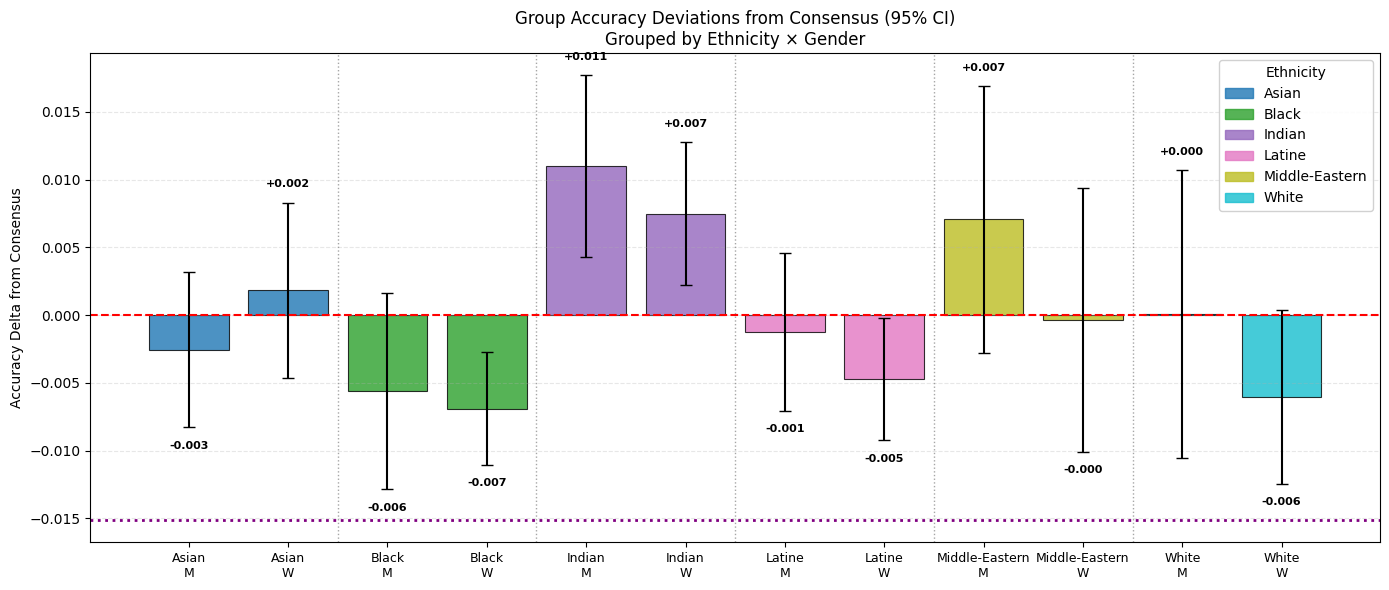


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.003    [-0.008, +0.003]5    
asian_woman         +0.002    [-0.005, +0.008]5    
black_man           -0.006    [-0.013, +0.002]5    
black_woman         -0.007    [-0.011, -0.003]5    
indian_man          +0.011    [+0.004, +0.018]5    
indian_woman        +0.007    [+0.002, +0.013]5    
latine_man          -0.001    [-0.007, +0.005]5    
latine_woman        -0.005    [-0.009, -0.000]5    
middle_eastern_man  +0.007    [-0.003, +0.017]5    
middle_eastern_woman-0.000    [-0.010, +0.009]5    
white_man           +0.000    [-0.011, +0.011]5    
white_woman         -0.006    [-0.012, +0.000]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: stereotype
Category columns analyzed: ['stereotype_type']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [50]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=stereotypes_case,
                                                    df = sample_mgsd, 
                                                    person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 64)
Using provided group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 64)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.732000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.716467  0.007873
woman      30  0.713800  0.006630

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7148  0.005095
black              10  0.7094  0.004526
indian             10  0.7236  0.004881
latine             10  0.7124  0.004300
middle_eastern     10  0.7182  0.008244


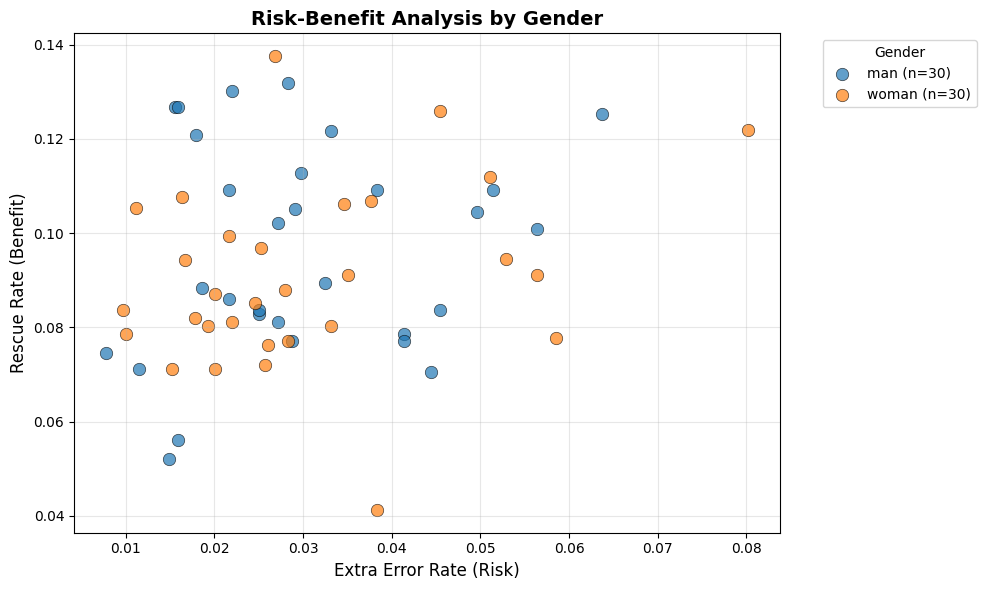


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


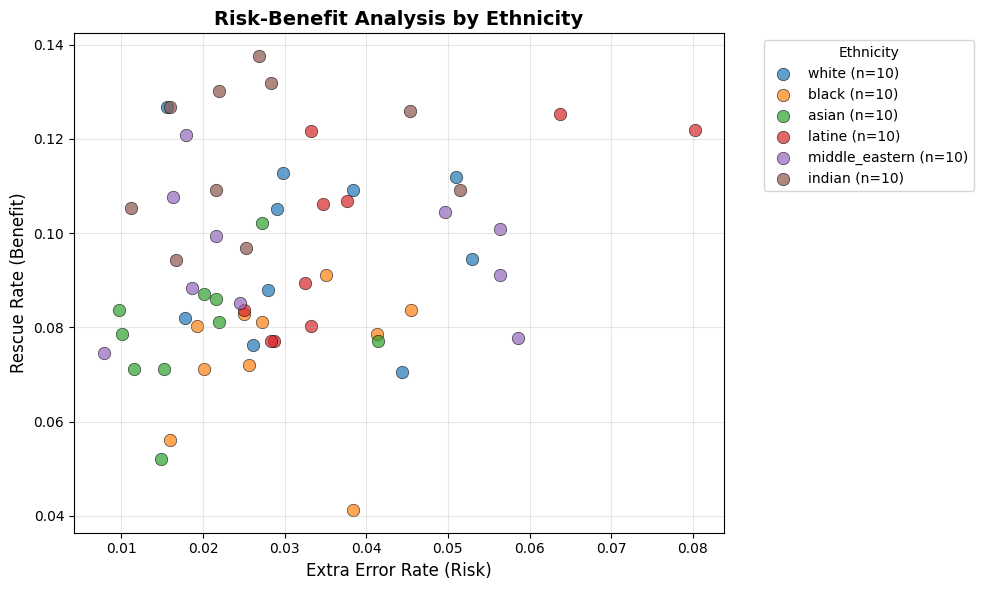


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


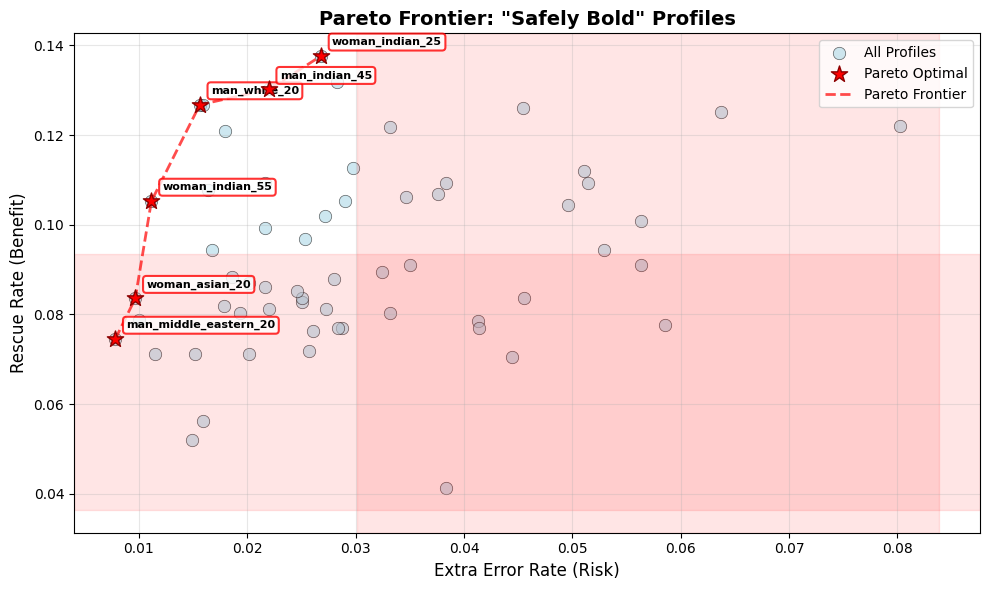


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (6 found):
  man_white_20 (profile1)
    Rescue Rate: 0.127, Extra Error Rate: 0.016
    Total Rescued: 25, Total Extra Errors: 10
  woman_asian_20 (profile26)
    Rescue Rate: 0.084, Extra Error Rate: 0.010
    Total Rescued: 18, Total Extra Errors: 6
  man_middle_eastern_20 (profile41)
    Rescue Rate: 0.074, Extra Error Rate: 0.008
    Total Rescued: 16, Total Extra Errors: 5
  man_indian_45 (profile54)
    Rescue Rate: 0.130, Extra Error Rate: 0.022
    Total Rescued: 24, Total Extra Errors: 10
  woman_indian_25 (profile57)
    Rescue Rate: 0.138, Extra Error Rate: 0.027
    Total Rescued: 26, Total Extra Errors: 13
  woman_indian_55 (profile60)
    Rescue Rate: 0.105, Extra Error Rate: 0.011
    Total Rescued: 20, Total Extra Errors: 7

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.094
  Average extra error rate: 0.030
  Best rescue rate: 0.138
  Lowest extra error rate: 0.008

Profile Arc

In [51]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=stereotypes_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7000

Ensemble Performance by Trait Group:
--

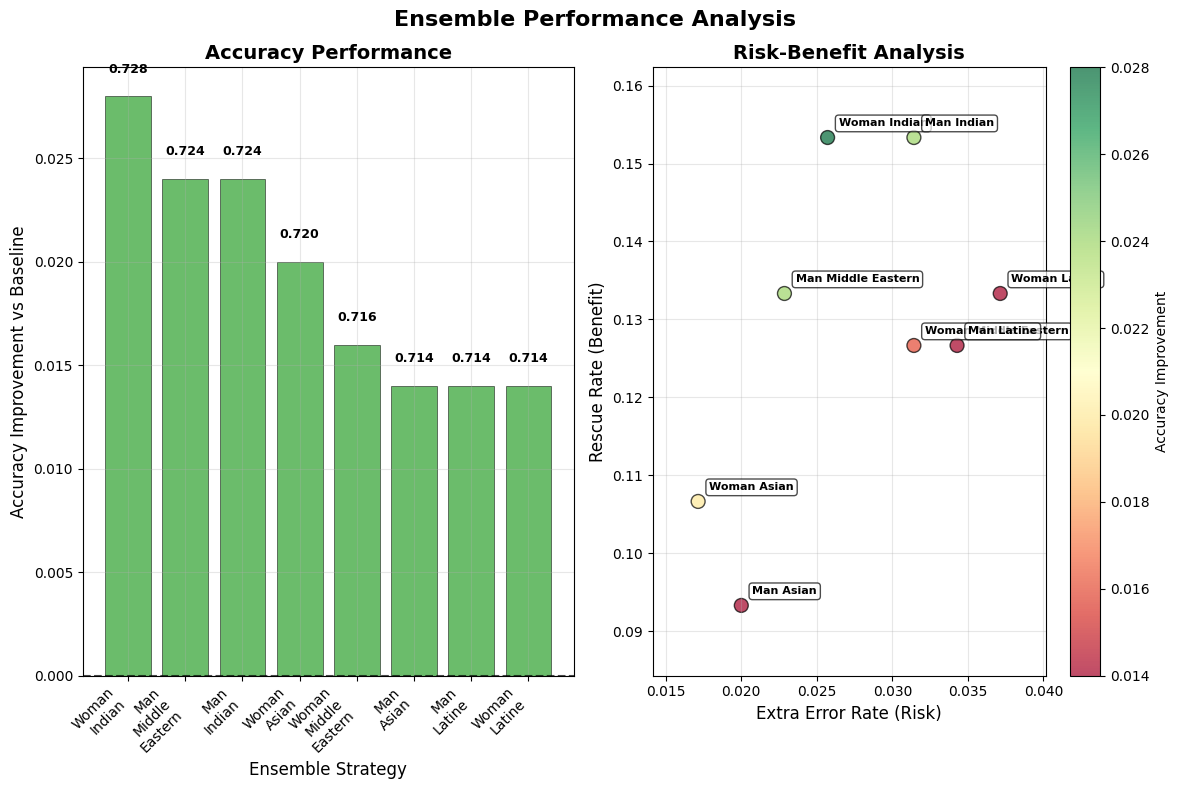

2. Cluster Analysis...


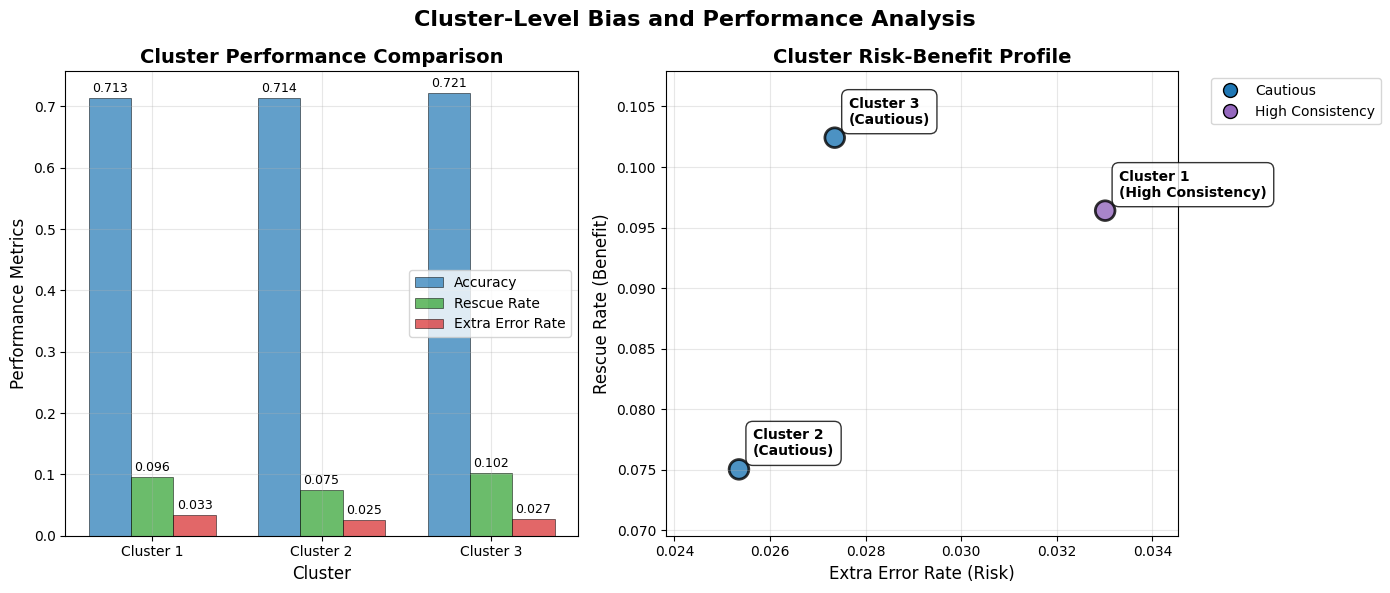

4. System-Level Recommendations...


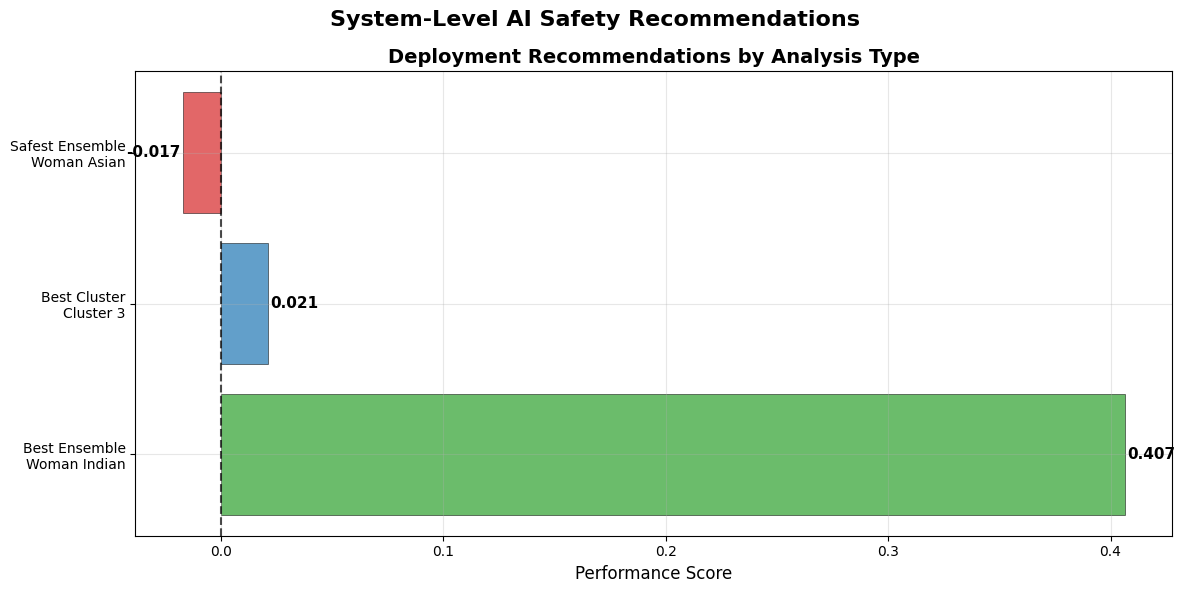


Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_indian
   • Best Cluster: cluster_3
   • Cognitive style analysis skipped: No cognitive style data found


In [52]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=stereotypes_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in stereotype_type: ['gender', 'profession', 'race', 'religion']
Creating simplified boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.093, p=0.4779 
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=-0.093, p=0.4817 
    → Negative correlation means more consistent 

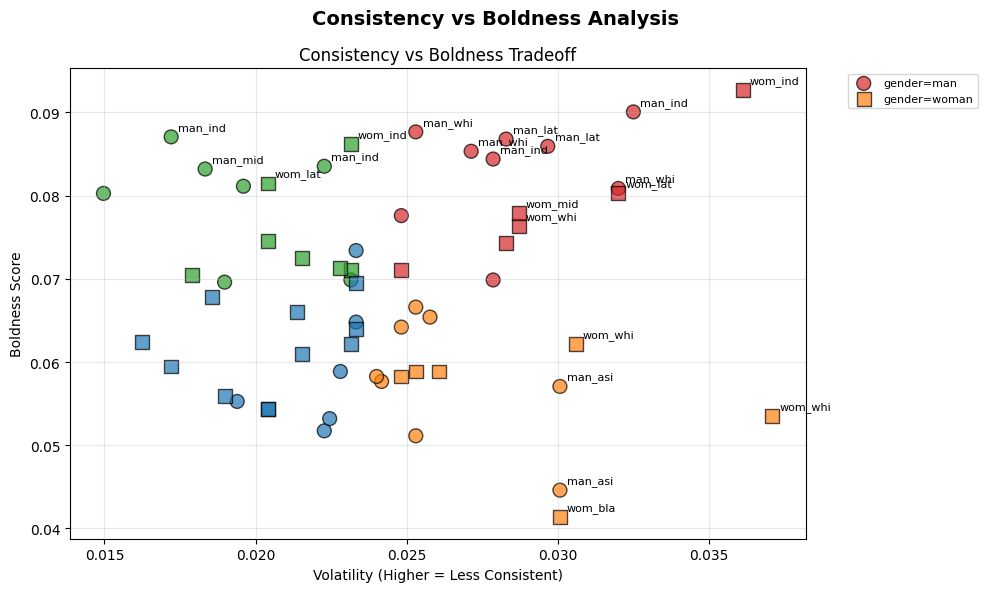

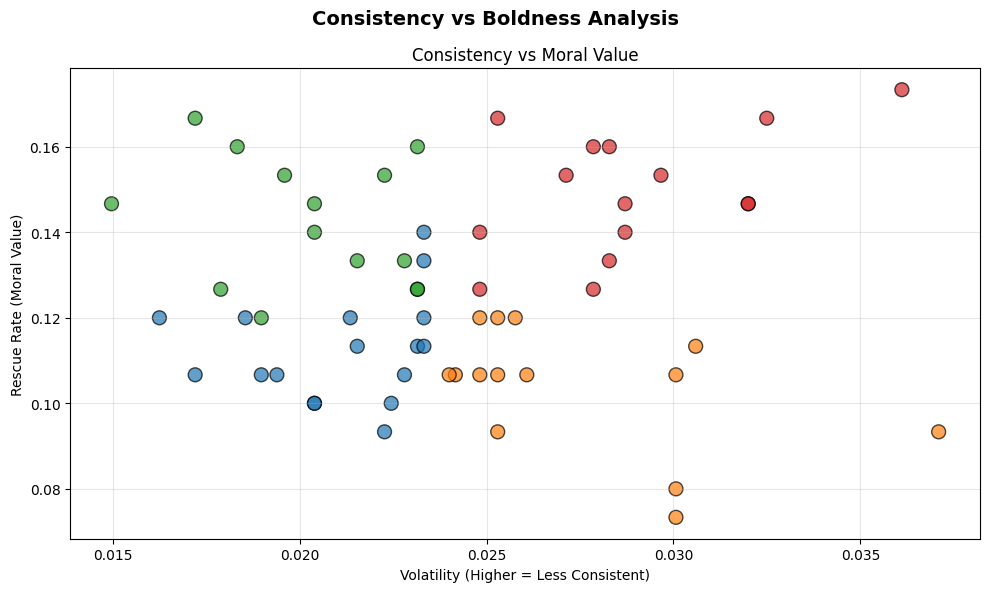

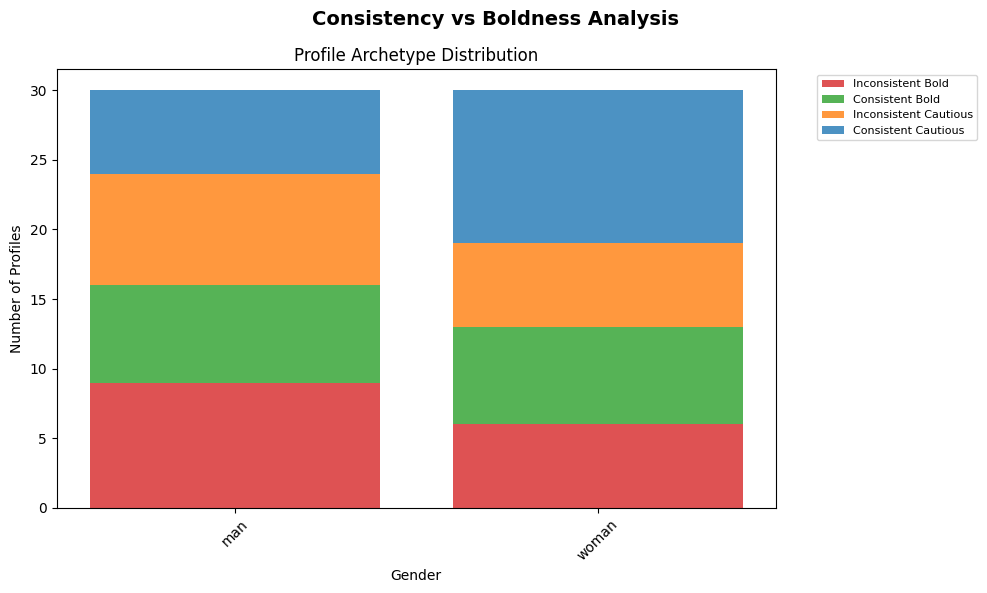

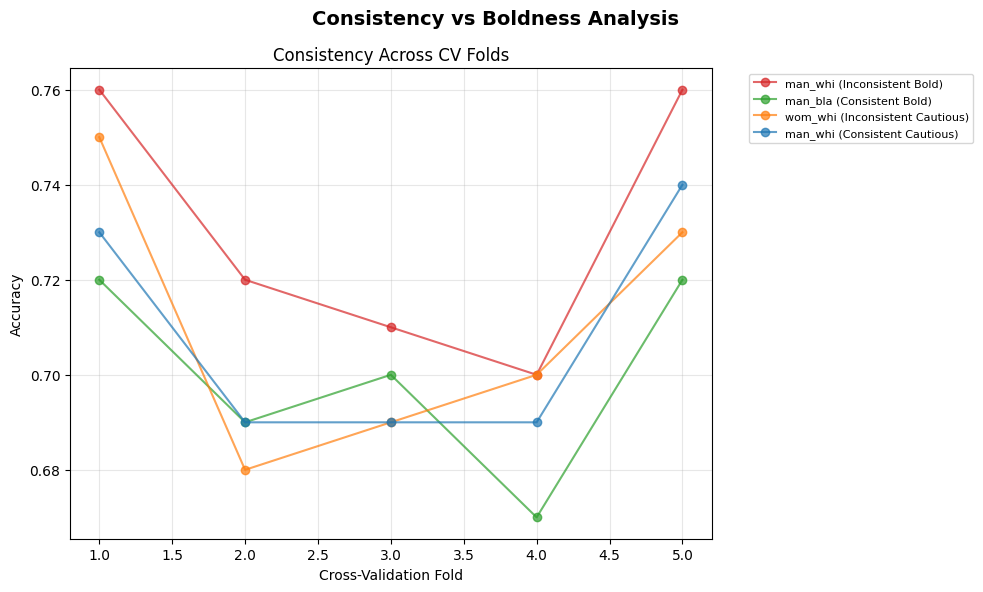

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


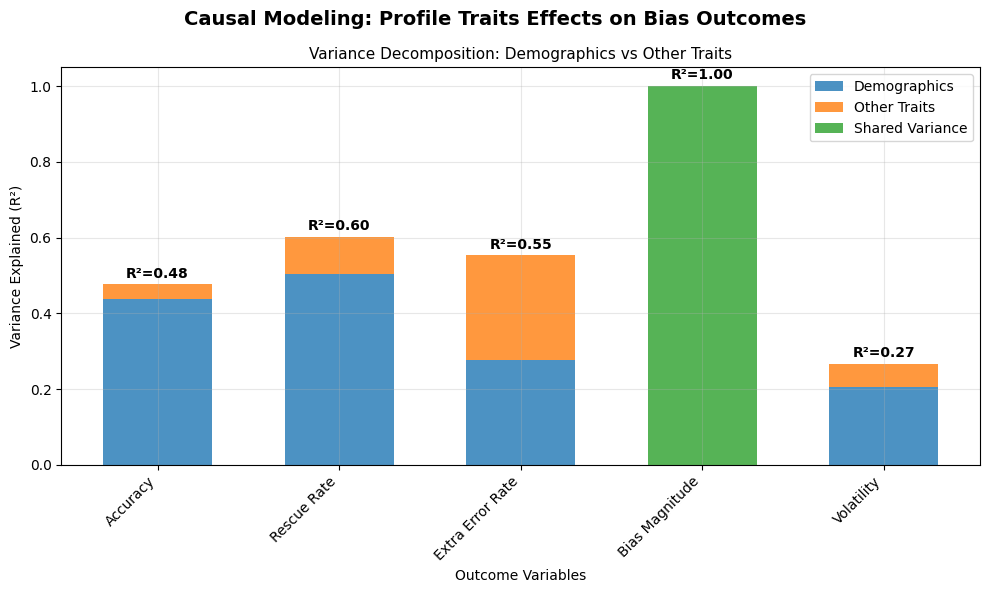

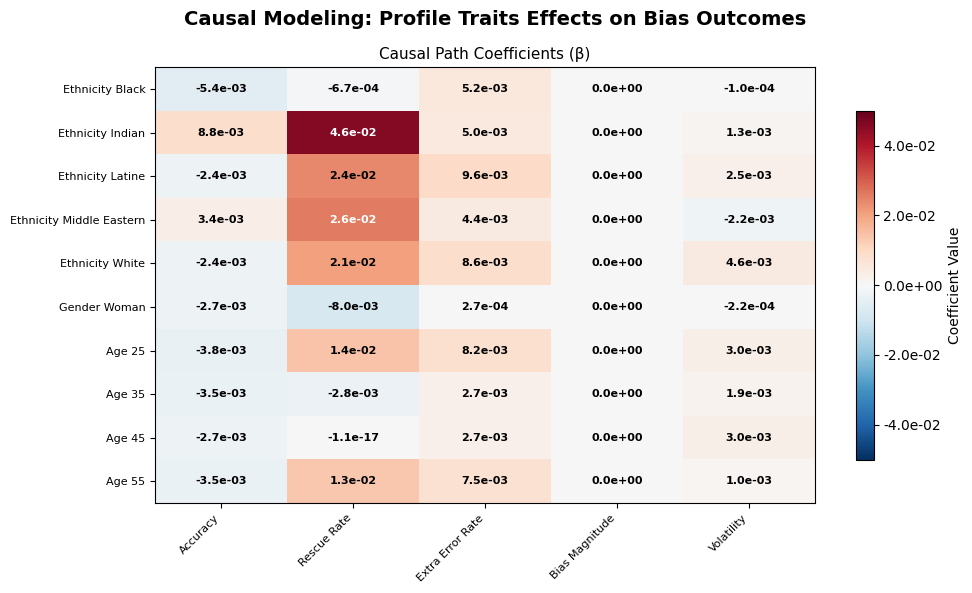

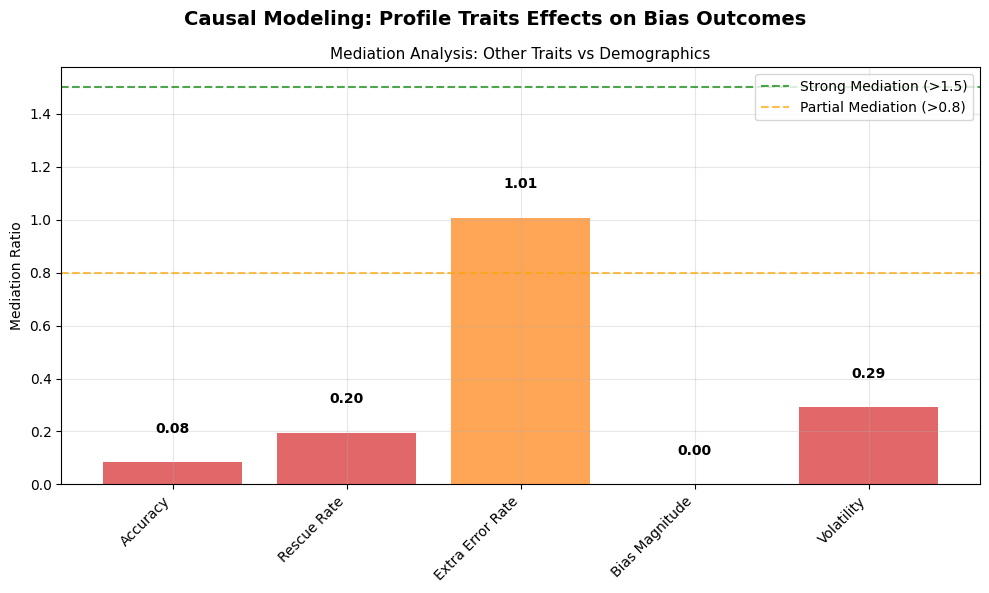

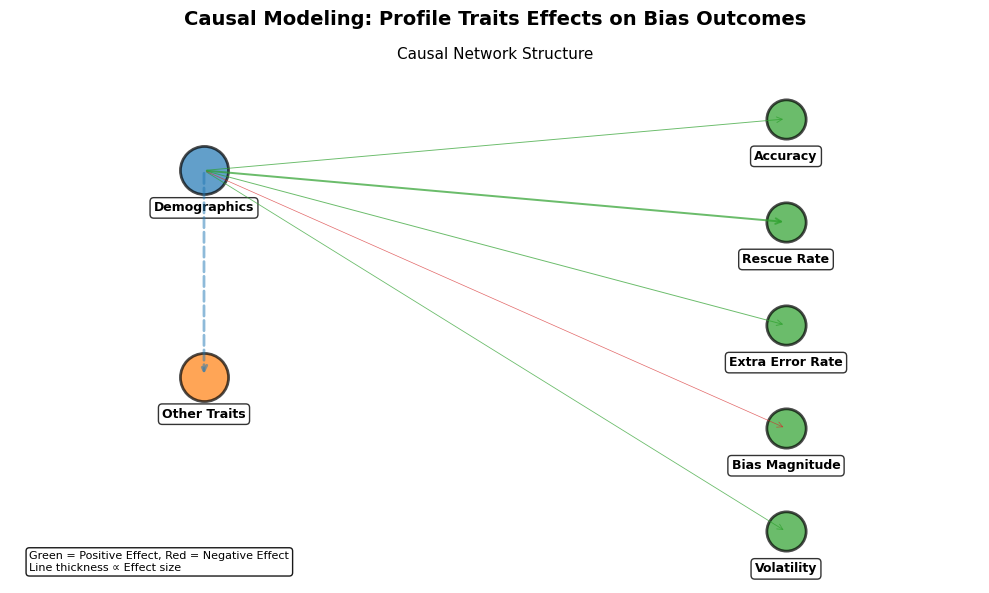

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.127 vs Consistent: 0.126
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 3 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [53]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                       case=stereotypes_case,
                                       )

# Chain-of-Thoughts
### Analysis results zero-shot - stereotype detection

In [54]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 15 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile41', 'profile42', 'profile43', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 15/15
[INFO] 45 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 15
Significant Differences Found: 2
Statistical Significance Rate: 13.3%

LARGEST EFFECT SIZES
----------------------------------------
 1. age_age.age_1_vs_age.age_5          Effect Size: -4.243 (Large)
 2. indian_vs_middle_eastern            Effect Size:  2.735 (Large)
 3. age_age.age_1_vs_age.age_4          Effect Size: -1.940 (Large)
 4. age_age.age_1_vs_age.age_2          Effect Size: -1.463 (Large)
 5. men_vs_women                        Effect Size: -1.432 (Large)

DETAILED SIGNIFICANT RESULTS
[SIGNIFICANT] men_vs_women                        | Man: 0.739 |

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


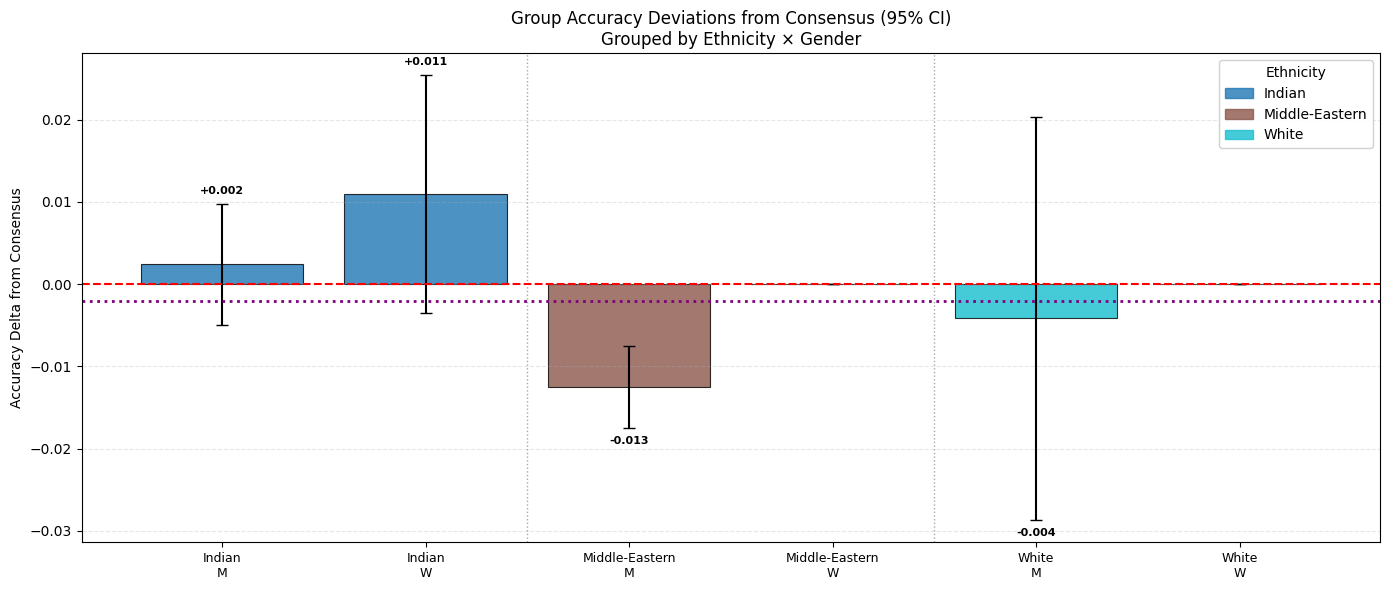


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
indian_man          +0.002    [-0.005, +0.010]5    
indian_woman        +0.011    [-0.004, +0.025]4    
middle_eastern_man  -0.013    [-0.017, -0.008]3    
middle_eastern_woman+0.000    [+0.000, +0.000]0    
white_man           -0.004    [-0.029, +0.020]3    
white_woman         +0.000    [+0.000, +0.000]0    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: stereotype
Category columns analyzed: ['stereotype_type']
Missing category columns: []
Total profiles: 15
Group keys used: ('gender', 'ethnicity', 'age')


In [55]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 19)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 19)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 15 profile columns

Performance data shape: (15, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.730000 - 0.758000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        11  0.739091  0.007713
woman       4  0.750000  0.009092

ETHNICITY:
                count      mean       std
ethnicity                                
indian              9  0.746444  0.007732
middle_eastern      3  0.732000  0.002000
white         

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1527: RuntimeWarning: invalid value encountered in multiply
  cov_p = self.normalized_cov_params * scale
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1527: RuntimeWarning: invalid value encountered in multiply
  cov_p = self.normalized_cov_params * scale
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  res = hypotest_fun_out(*samp

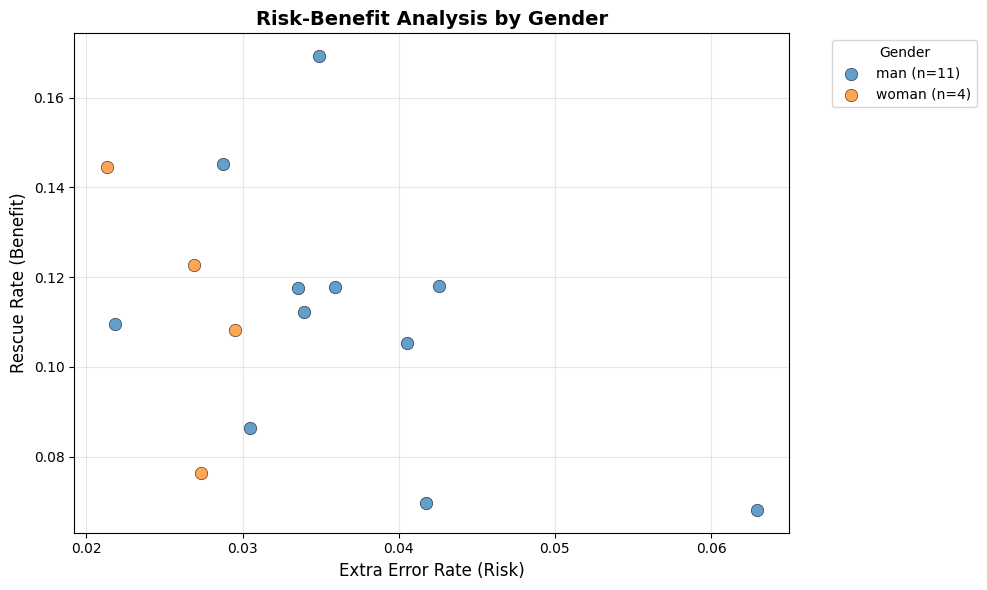


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'middle_eastern', 'indian']


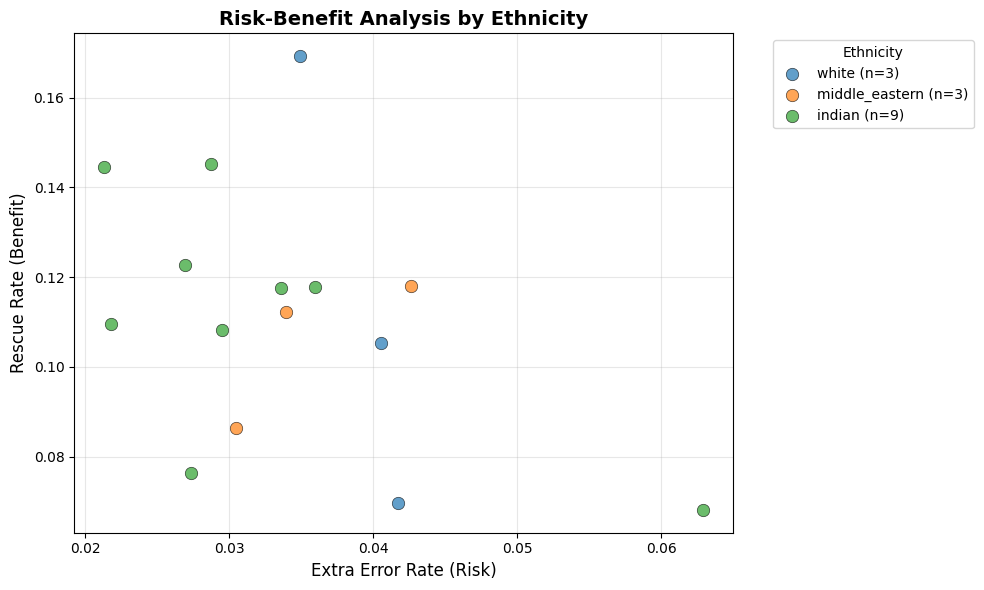


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


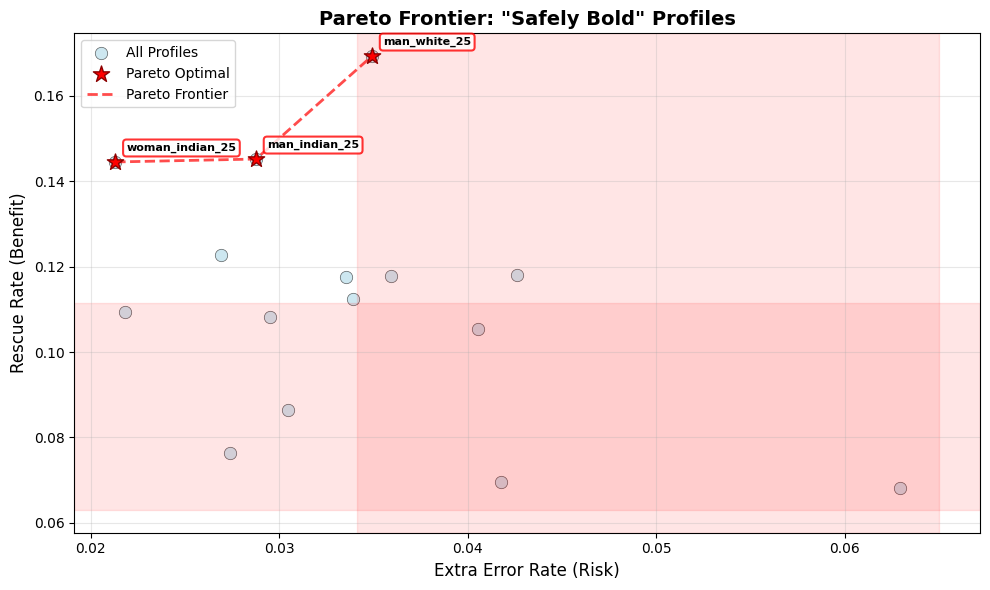


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (3 found):
  man_white_25 (profile2)
    Rescue Rate: 0.169, Extra Error Rate: 0.035
    Total Rescued: 19, Total Extra Errors: 14
  man_indian_25 (profile52)
    Rescue Rate: 0.145, Extra Error Rate: 0.029
    Total Rescued: 15, Total Extra Errors: 12
  woman_indian_25 (profile57)
    Rescue Rate: 0.145, Extra Error Rate: 0.021
    Total Rescued: 17, Total Extra Errors: 8

Risk-Benefit Statistics:
  Total profiles analyzed: 15
  Average rescue rate: 0.111
  Average extra error rate: 0.034
  Best rescue rate: 0.169
  Lowest extra error rate: 0.021

Profile Archetypes:
  Safest Profile: woman_indian_25 (profile57)
    Extra Error Rate: 0.021
  Most Beneficial Profile: man_white_25 (profile2)
    Rescue Rate: 0.169

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 2 (66.7%)
    woman: 1 (33.3%)
  Ethnicity:
    indian: 2 (66.7%)
    white: 1 (33.3%)
  Age:
=== Pareto frontier analysis completed successfully


/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [56]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=stereotypes_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 19)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 19)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 15 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['indian', 'middle_eastern', 'white']
Created 4 trait groups:
  man_indian: 5 profiles
  man_middle_eastern: 3 profiles
  man_white: 3 profiles
  woman_indian: 4 profiles
Baseline accuracy: 0.7400

Ensemble Performance by Trait Group:
--------------------------------------------------
man_white                     : 0.7420 (+0.0020) | Rescue: 0.115 | Extra Err: 0.038 | n=3
man_middle_eastern            : 0.7300 (-0.0100) | Rescue: 0.069 | Extra Err: 0.038 | n=3
man_indian   

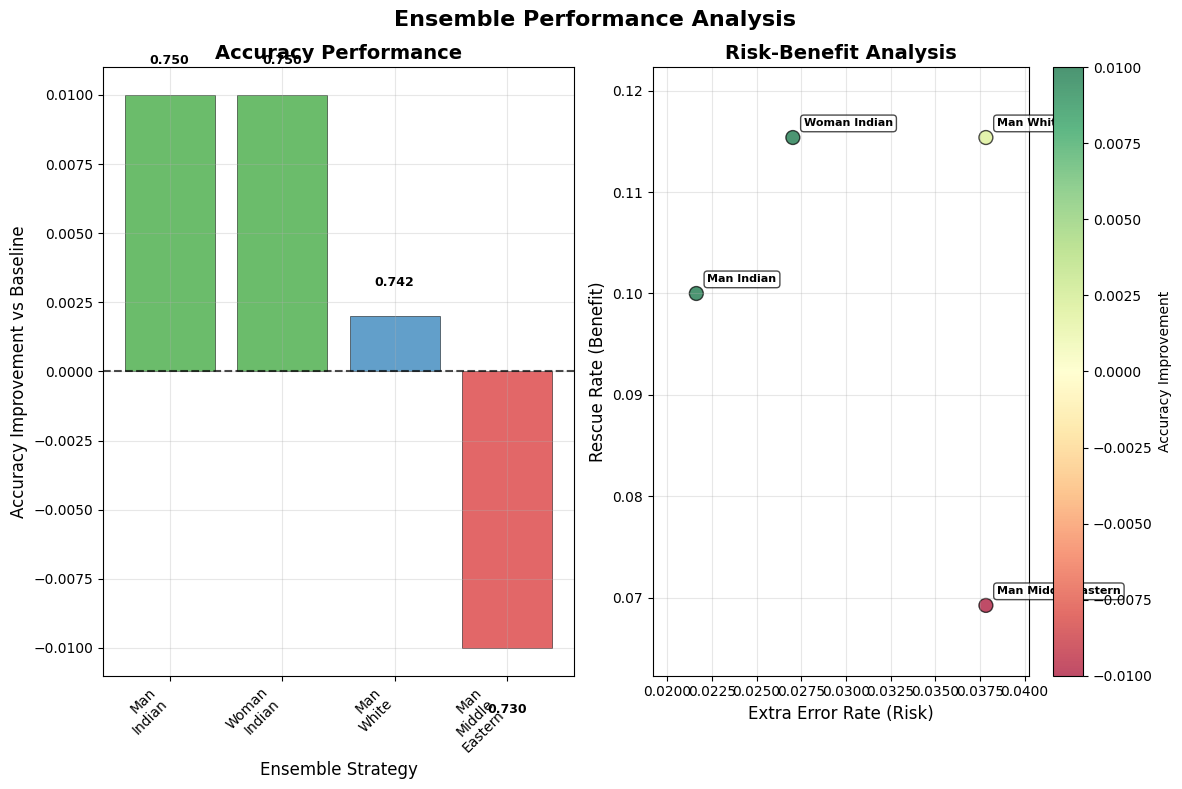

2. Cluster Analysis...


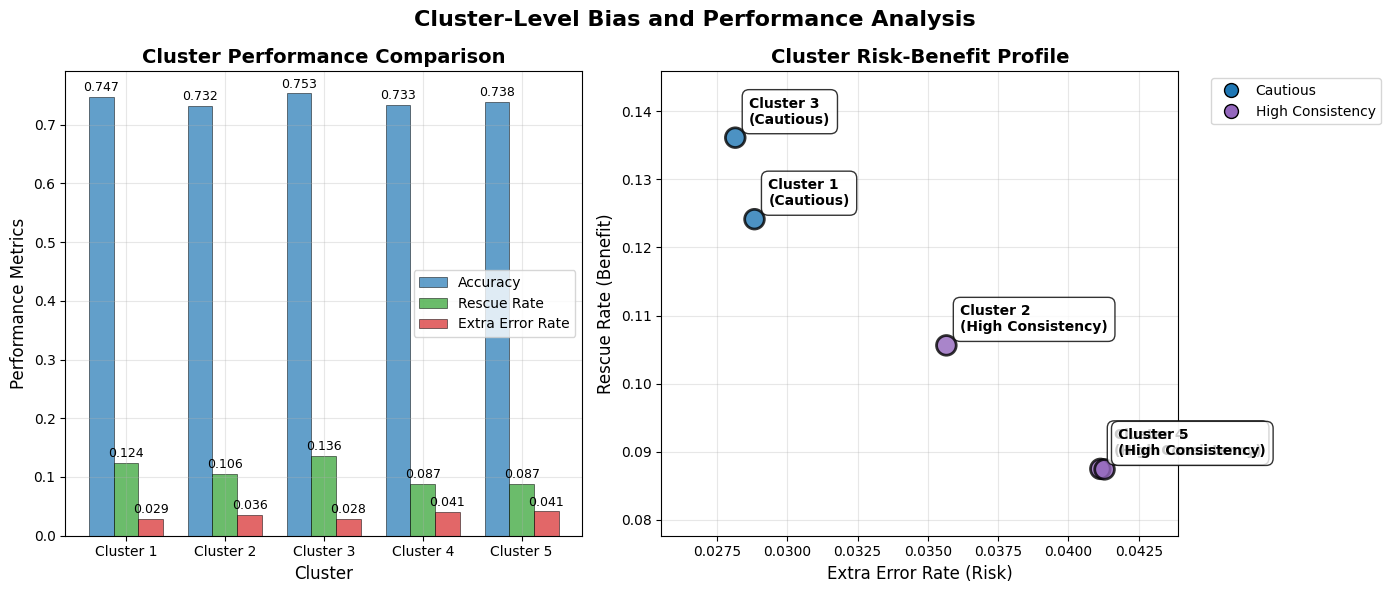

4. System-Level Recommendations...


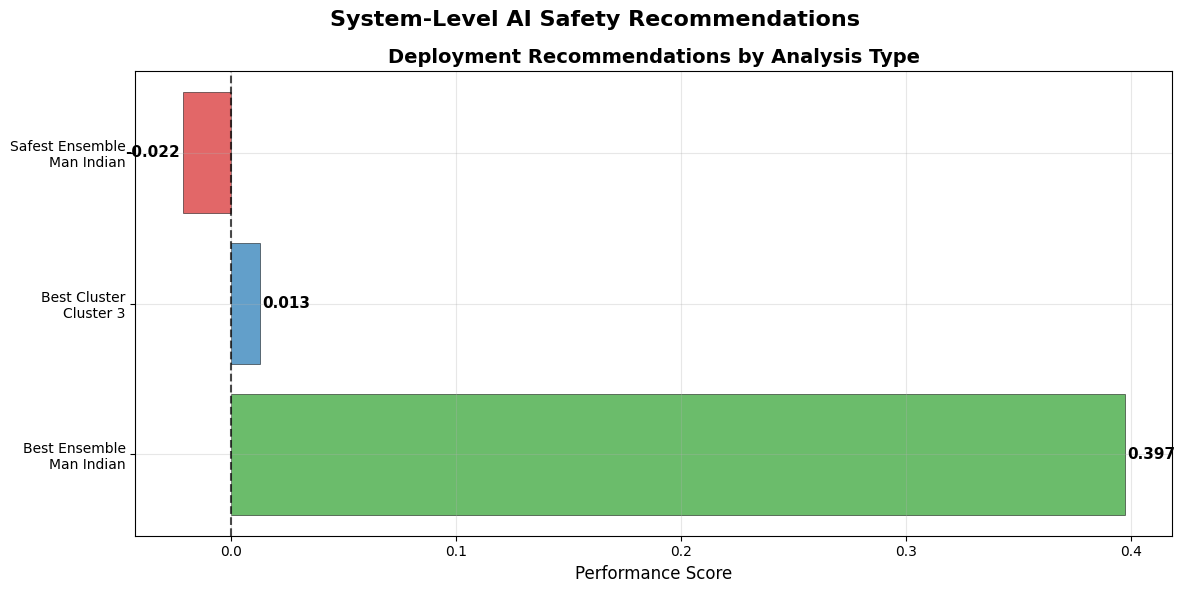


Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_3
   • Cognitive style analysis skipped: No cognitive style data found


In [57]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 15 valid profiles out of 15 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in stereotype_type: ['gender', 'profession', 'race', 'religion']
Creating simplified boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (15, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.008, p=0.9768 
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=-0.007, p=0.9807 
    → Negative correlation means more consistent 

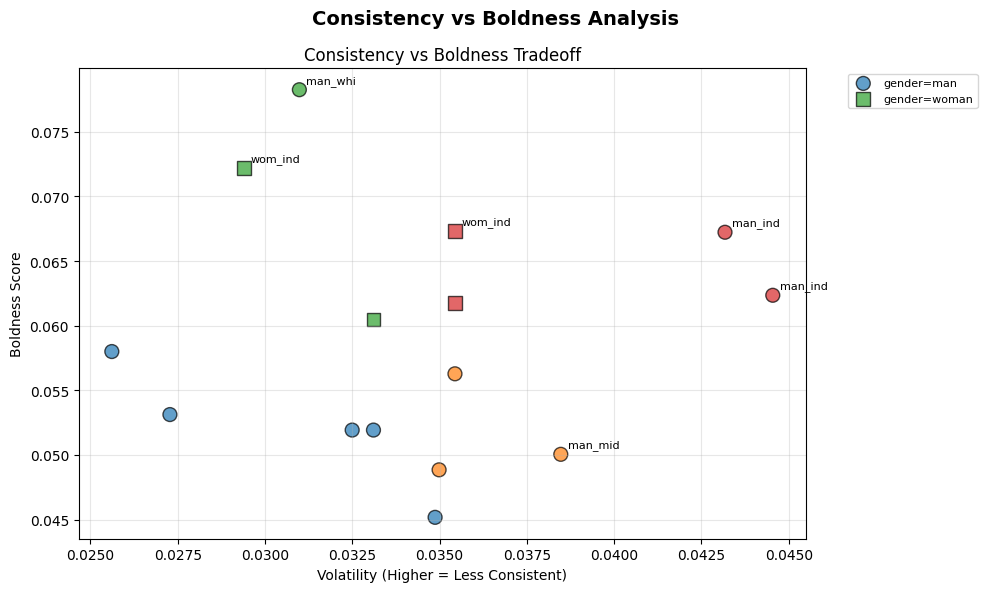

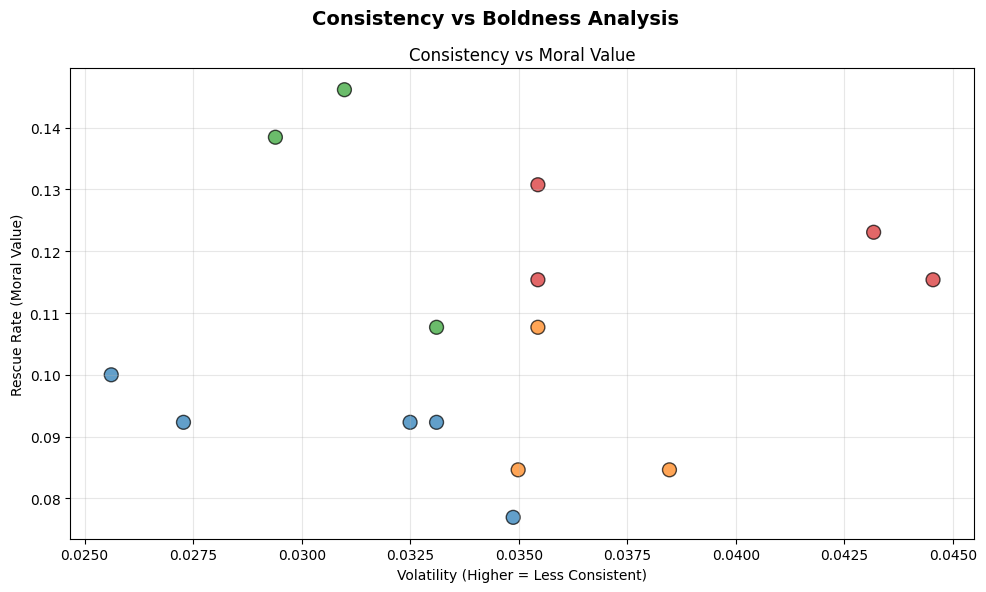

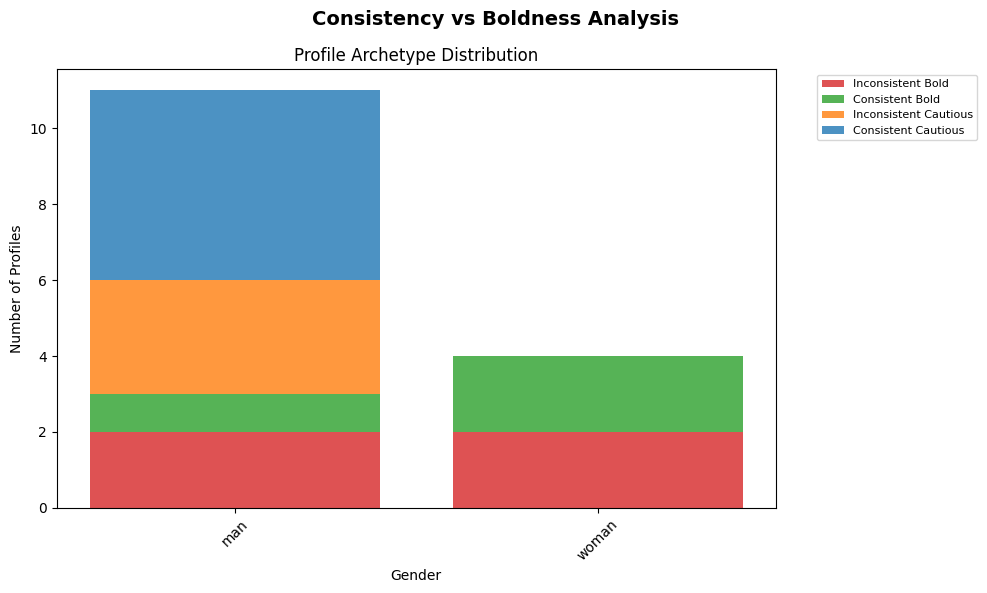

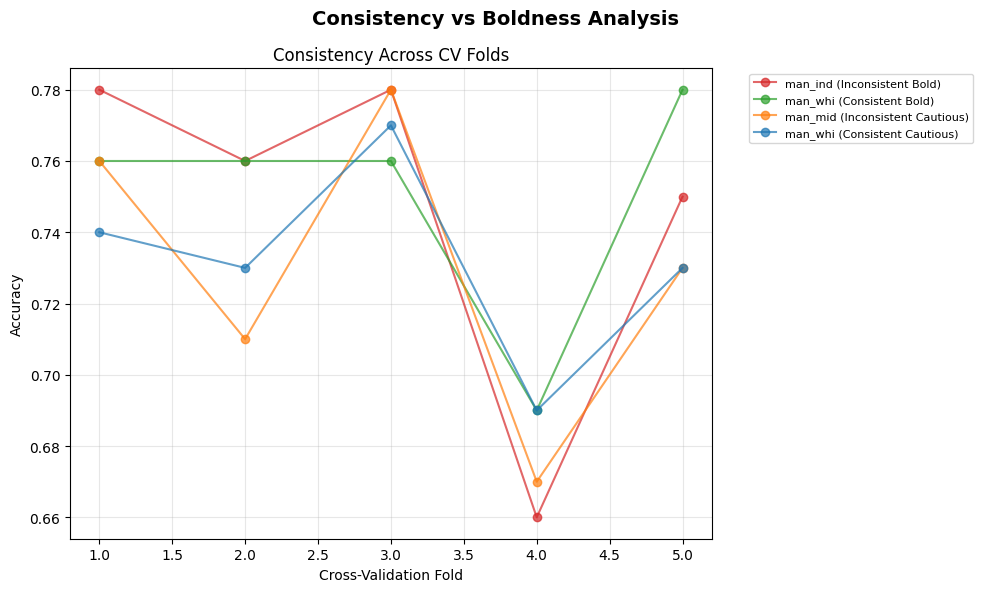

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


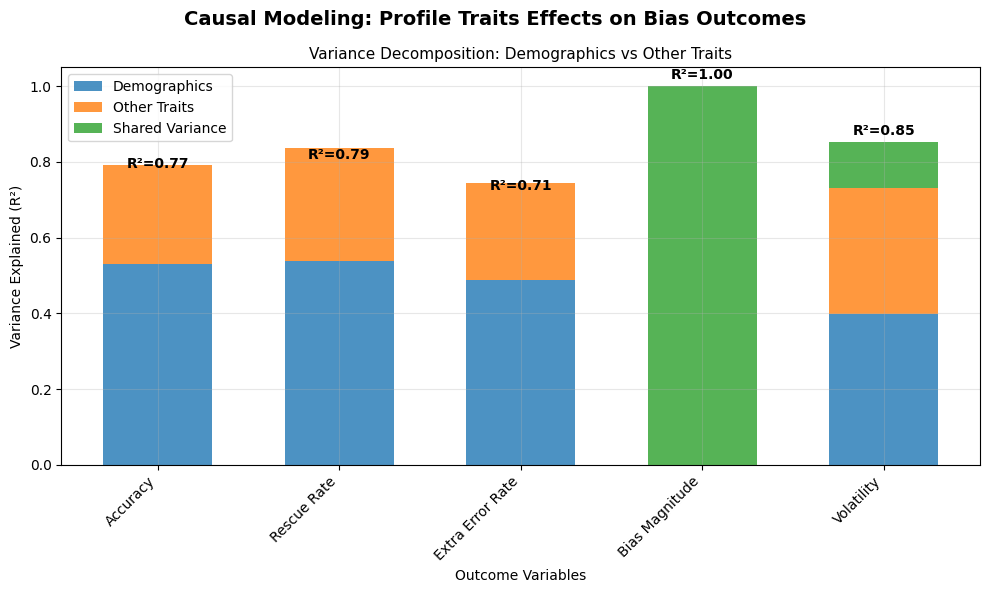

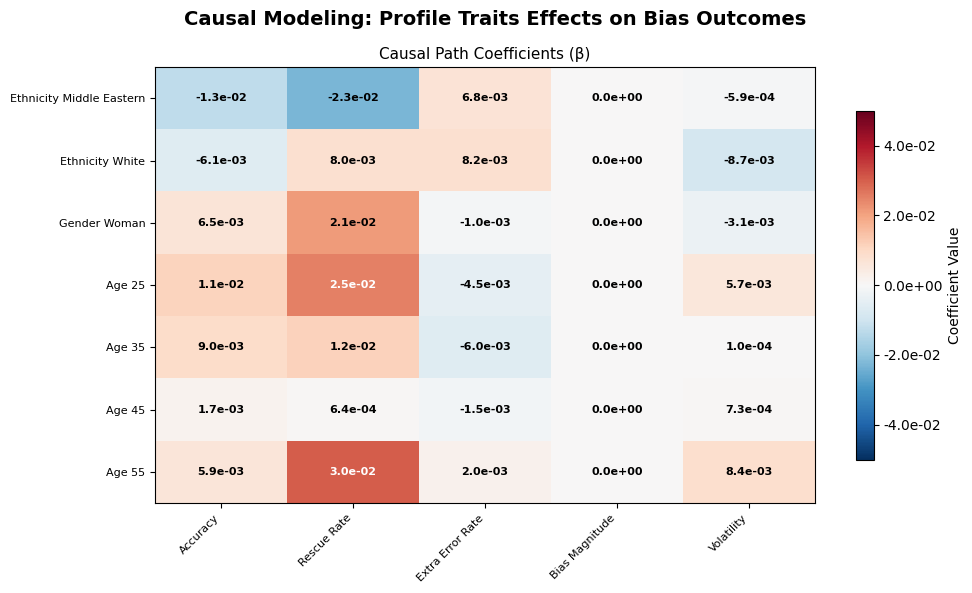

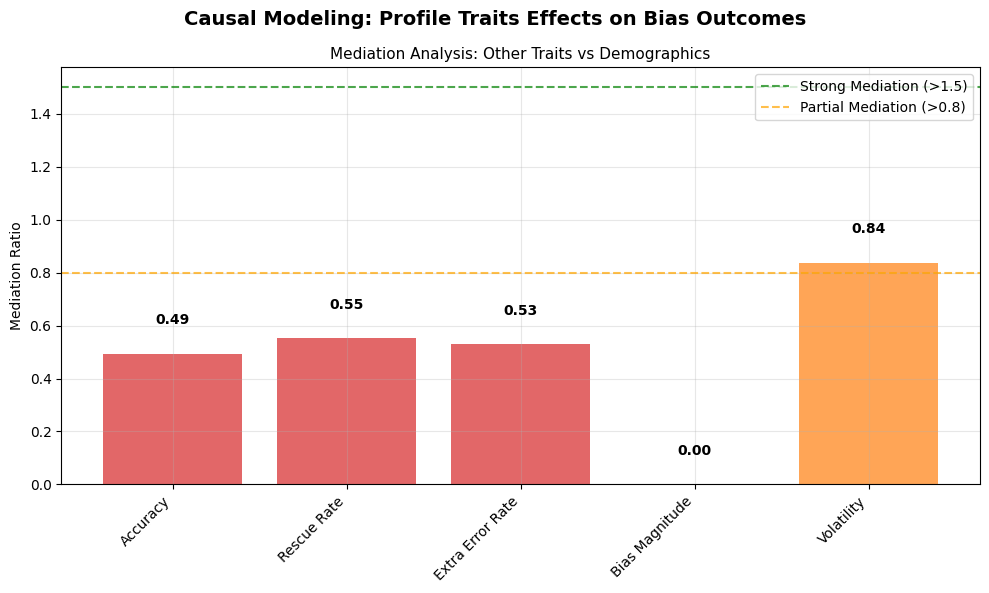

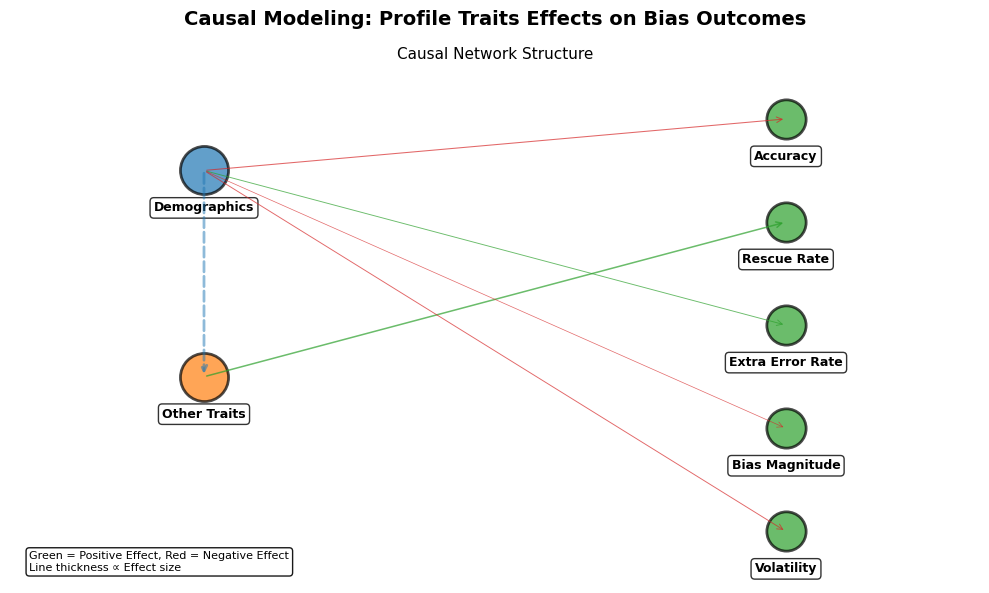

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.109 vs Consistent: 0.106
   - Strongest predictor of moral value (rescue): age_55
   - Strongest predictor of performance (accuracy): ethnicity_middle_eastern
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 1 high, 3 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 15 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [58]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=stereotypes_case)